# 05 - Modeling (LightGBM + SMOTE + SHAP)

## 1. Setup
Trains LightGBM classifiers to predict PM2.5 spikes at t+1, t+2, t+3 hours
ahead. Handles the ~0.88% class imbalance with SMOTE, evaluates with
F1/Recall/Precision/ROC-AUC/PR-AUC (NOT accuracy - misleading on this
imbalanced a target), and runs SHAP for explainability.

In [10]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import (
    f1_score, recall_score, precision_score, roc_auc_score,
    average_precision_score, confusion_matrix
)
from imblearn.over_sampling import SMOTE

HORIZONS = [1, 2, 3]
USE_SMOTE = True

NON_FEATURE_COLS = [
    "No", "year", "month", "day", "hour", "wd", "datetime",
    "spike_t+1", "spike_t+2", "spike_t+3",
]

## 2. Load feature data

In [11]:
train = pd.read_csv("train_features_v2.csv")
test = pd.read_csv("test_features_v2.csv")
train["datetime"] = pd.to_datetime(train["datetime"])
test["datetime"] = pd.to_datetime(test["datetime"])

def get_feature_cols(df):
    return [c for c in df.columns if c not in NON_FEATURE_COLS]

def prep_xy(df, feature_cols, target_col):
    X = df[feature_cols].copy()
    y = df[target_col].astype(int)
    X["station"] = X["station"].astype("category")
    return X, y

train.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,idw_pm25_neighbors,idw_wind_u_neighbors,idw_wind_v_neighbors,regional_elevated_frac,spike_t+1,spike_t+2,spike_t+3,in_plume,plume_size,apriori_propagation_signal
0,173665,2022,8,5,0,8.5,13.5,1.0,3.1,118.0,...,12.469896,-1.727341,-0.125239,0.0,0,0,0,0,0.0,0.0
1,173666,2022,8,5,1,7.1,11.5,1.1,2.9,119.0,...,10.508043,-1.644307,0.118206,0.0,0,0,0,0,0.0,0.0
2,173667,2022,8,5,2,6.4,10.3,1.1,2.7,120.0,...,8.198478,-1.921739,0.954034,0.0,0,0,0,0,0.0,0.0
3,173668,2022,8,5,3,6.3,9.9,1.1,2.3,119.0,...,7.725460,-2.055481,1.598997,0.0,0,0,0,0,0.0,0.0
4,173669,2022,8,5,4,5.8,9.1,1.0,2.1,117.0,...,8.758535,-2.352543,1.386802,0.0,0,0,0,0,0.0,0.0


## 3. Train one model per horizon
`station` is kept as a native LightGBM categorical (no need to one-hot for
the model itself). SMOTE is applied to the training set only - one-hot
encoding `station` temporarily since SMOTE needs numeric input, then
collapsing back to a single categorical column afterward.

In [12]:
def train_one_horizon(train, test, horizon):
    target_col = f"spike_t+{horizon}"
    feature_cols = get_feature_cols(train)

    X_train, y_train = prep_xy(train, feature_cols, target_col)
    X_test, y_test = prep_xy(test, feature_cols, target_col)

    print(f"\n{'='*60}\nHorizon t+{horizon}h | train={len(X_train)} test={len(X_test)} "
          f"| train spike rate={y_train.mean()*100:.3f}%")

    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    if USE_SMOTE:
        X_train_ohe = pd.get_dummies(X_train, columns=["station"])
        sm = SMOTE(random_state=42, k_neighbors=5)
        X_res, y_res = sm.fit_resample(X_train_ohe, y_train)
        station_cols = [c for c in X_res.columns if c.startswith("station_")]
        X_res["station"] = X_res[station_cols].idxmax(axis=1).str.replace("station_", "", regex=False)
        X_res = X_res.drop(columns=station_cols)
        X_res["station"] = X_res["station"].astype("category")
        print(f"After SMOTE: {len(X_res)} rows, spike rate={y_res.mean()*100:.2f}%")
    else:
        X_res, y_res = X_train, y_train

    model = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=31, max_depth=-1,
        scale_pos_weight=1.0 if USE_SMOTE else scale_pos_weight,
        random_state=42, n_jobs=-1, verbosity=-1,
    )
    model.fit(
        X_res, y_res, categorical_feature=["station"],
        eval_set=[(X_test, y_test)], eval_metric="average_precision",
        callbacks=[lgb.early_stopping(30, verbose=False)],
    )

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)

    metrics = {
        "horizon": horizon,
        "f1": f1_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_pred_proba),
        "pr_auc": average_precision_score(y_test, y_pred_proba),
    }
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    metrics.update({"tp": tp, "fp": fp, "fn": fn, "tn": tn})

    print(f"F1={metrics['f1']:.3f}  Recall={metrics['recall']:.3f}  "
          f"Precision={metrics['precision']:.3f}  ROC-AUC={metrics['roc_auc']:.3f}  "
          f"PR-AUC={metrics['pr_auc']:.3f}")
    print(f"Confusion matrix -> TP={tp} FP={fp} FN={fn} TN={tn}")

    return model, X_test, y_test, metrics

In [13]:
models = {}
all_metrics = []
test_sets = {}

for h in HORIZONS:
    model, X_test, y_test, metrics = train_one_horizon(train, test, h)
    models[h] = model
    test_sets[h] = (X_test, y_test)
    all_metrics.append(metrics)

results_df = pd.DataFrame(all_metrics)
results_df


Horizon t+1h | train=179280 test=28800 | train spike rate=0.881%
After SMOTE: 355400 rows, spike rate=50.00%


c:\Users\Ahnaf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
c:\Users\Ahnaf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\basic.py:2142: UserWarning: categorical_column in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


F1=0.427  Recall=0.963  Precision=0.275  ROC-AUC=0.997  PR-AUC=0.762
Confusion matrix -> TP=232 FP=613 FN=9 TN=27946

Horizon t+2h | train=179280 test=28800 | train spike rate=0.881%
After SMOTE: 355400 rows, spike rate=50.00%


c:\Users\Ahnaf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
c:\Users\Ahnaf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\basic.py:2142: UserWarning: categorical_column in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


F1=0.339  Recall=0.925  Precision=0.207  ROC-AUC=0.972  PR-AUC=0.343
Confusion matrix -> TP=223 FP=853 FN=18 TN=27706

Horizon t+3h | train=179280 test=28800 | train spike rate=0.881%
After SMOTE: 355400 rows, spike rate=50.00%


c:\Users\Ahnaf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
c:\Users\Ahnaf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\basic.py:2142: UserWarning: categorical_column in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


F1=0.228  Recall=0.793  Precision=0.133  ROC-AUC=0.959  PR-AUC=0.179
Confusion matrix -> TP=191 FP=1240 FN=50 TN=27319


,horizon,f1,recall,precision,roc_auc,pr_auc,tp,fp,fn,tn
0,1,0.427256,0.962656,0.274556,0.997220,0.762344,232,613,9,27946
1,2,0.338648,0.925311,0.207249,0.972090,0.342738,223,853,18,27706
2,3,0.228469,0.792531,0.133473,0.958655,0.178510,191,1240,50,27319


## 4. Confusion matrices, visualized

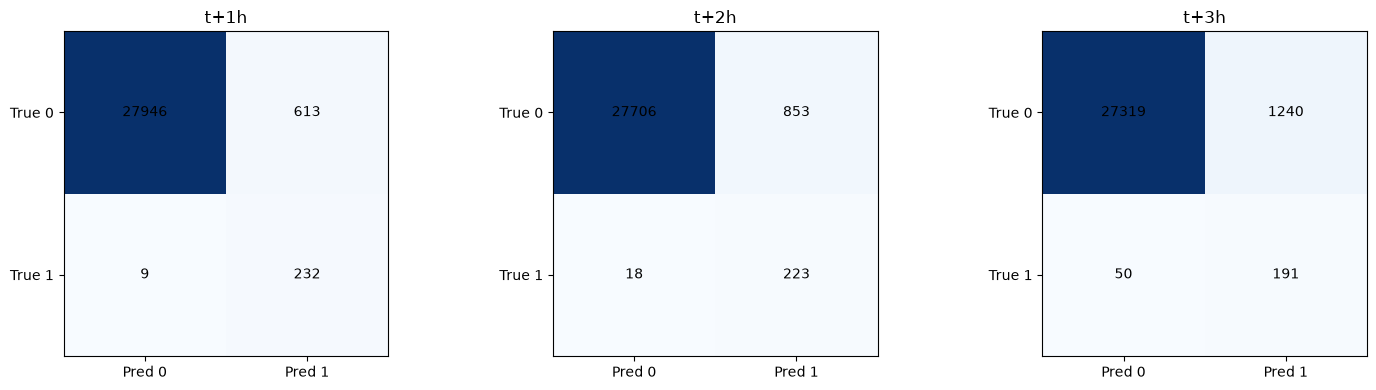

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, h in zip(axes, HORIZONS):
    row = results_df[results_df["horizon"] == h].iloc[0]
    cm = np.array([[row["tn"], row["fp"]], [row["fn"], row["tp"]]])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"t+{h}h")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["True 0", "True 1"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

## 5. Metrics across horizons

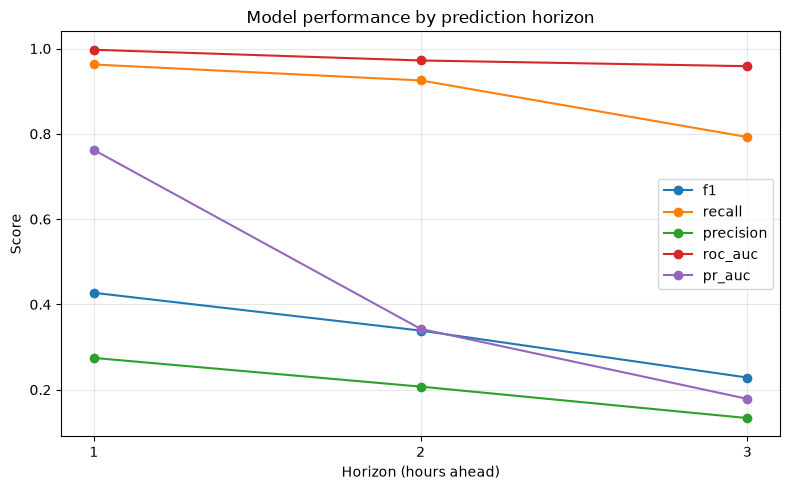

In [15]:
plt.figure(figsize=(8, 5))
for metric in ["f1", "recall", "precision", "roc_auc", "pr_auc"]:
    plt.plot(results_df["horizon"], results_df[metric], marker="o", label=metric)
plt.xlabel("Horizon (hours ahead)")
plt.ylabel("Score")
plt.title("Model performance by prediction horizon")
plt.xticks(HORIZONS)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. SHAP explainability\nRuns per-horizon TreeExplainer and plots feature importance inline.

c:\Users\Ahnaf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



--- SHAP summary plot: t+1h ---


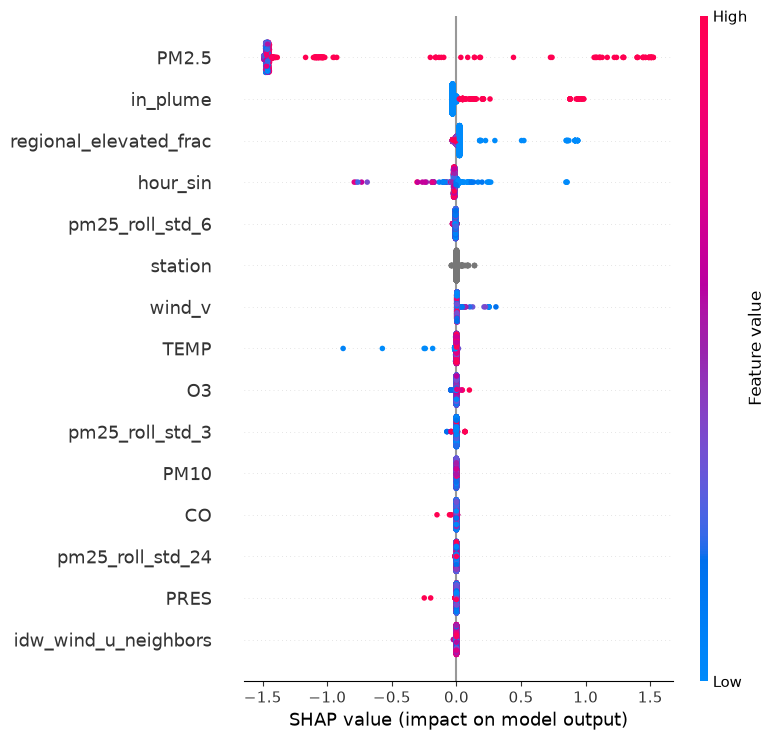


--- SHAP bar plot: t+1h ---


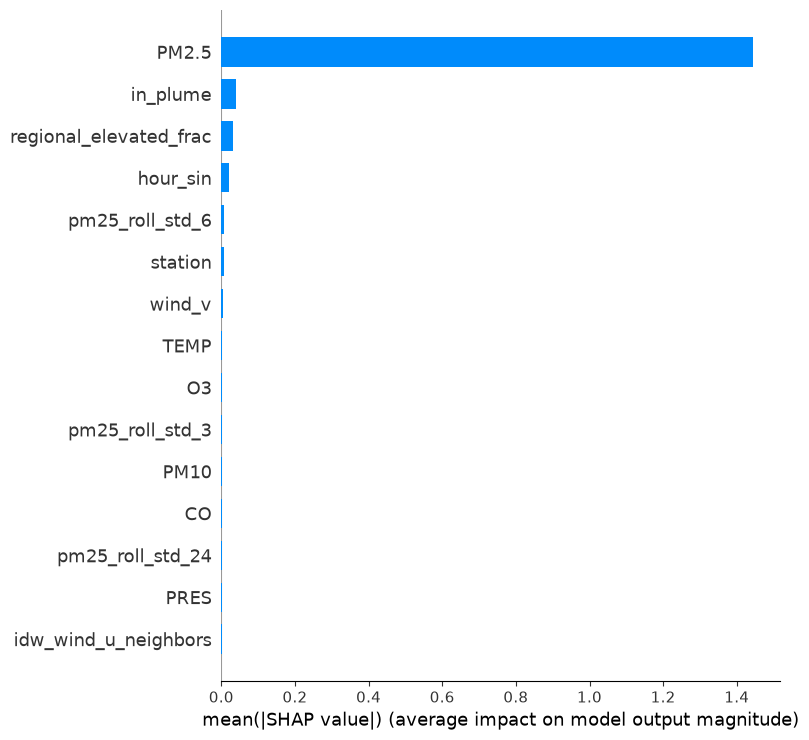


Top 10 SHAP features for t+1h:
PM2.5                     1.445116
in_plume                  0.039191
regional_elevated_frac    0.031389
hour_sin                  0.021495
pm25_roll_std_6           0.007401
station                   0.007031
wind_v                    0.004588
TEMP                      0.001963
O3                        0.001681
pm25_roll_std_3           0.001474
dtype: float64

--- SHAP summary plot: t+2h ---


c:\Users\Ahnaf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


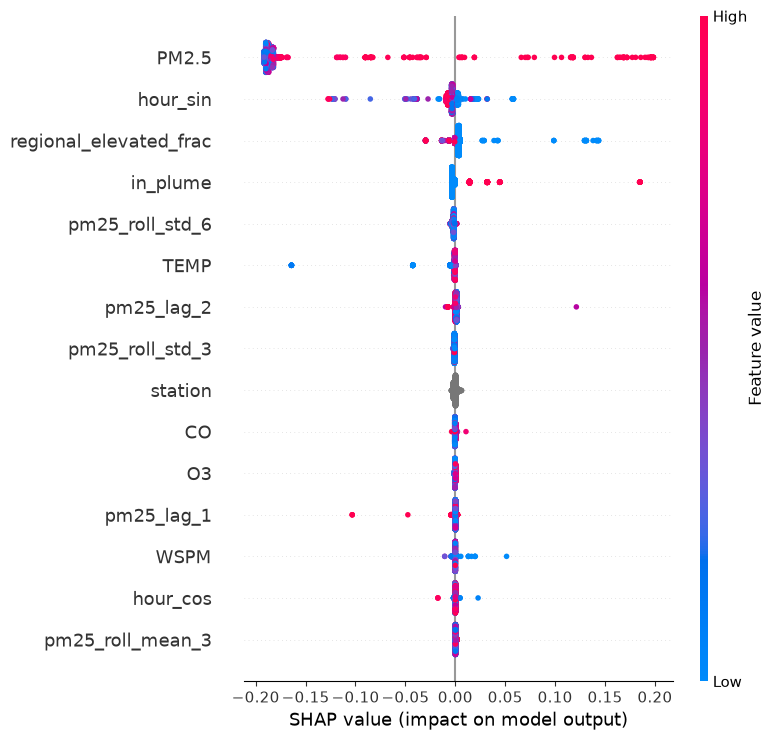


--- SHAP bar plot: t+2h ---


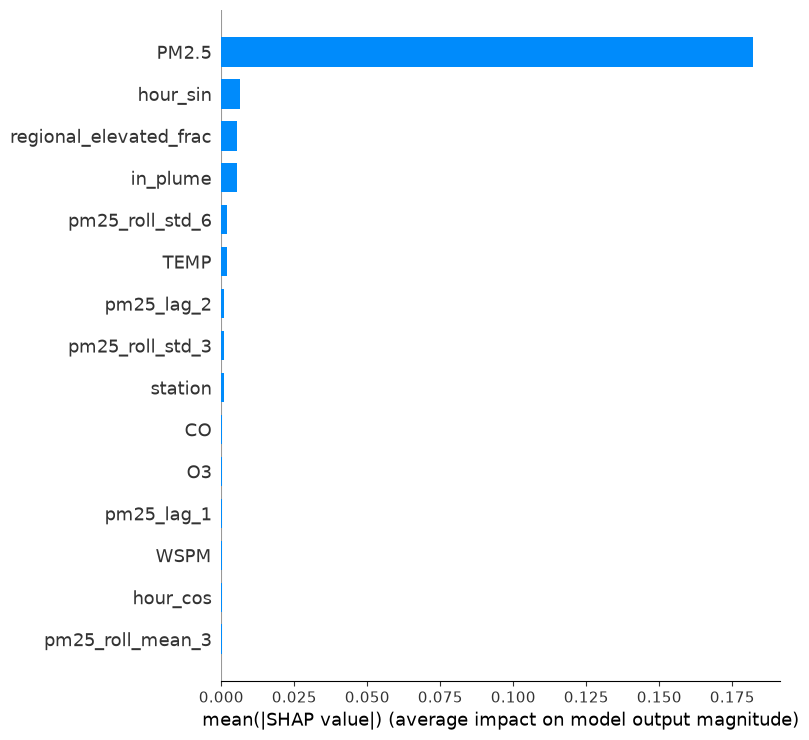


Top 10 SHAP features for t+2h:
PM2.5                     0.182212
hour_sin                  0.006356
regional_elevated_frac    0.005511
in_plume                  0.005410
pm25_roll_std_6           0.001872
TEMP                      0.001785
pm25_lag_2                0.001046
pm25_roll_std_3           0.000982
station                   0.000880
CO                        0.000373
dtype: float64

--- SHAP summary plot: t+3h ---


c:\Users\Ahnaf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


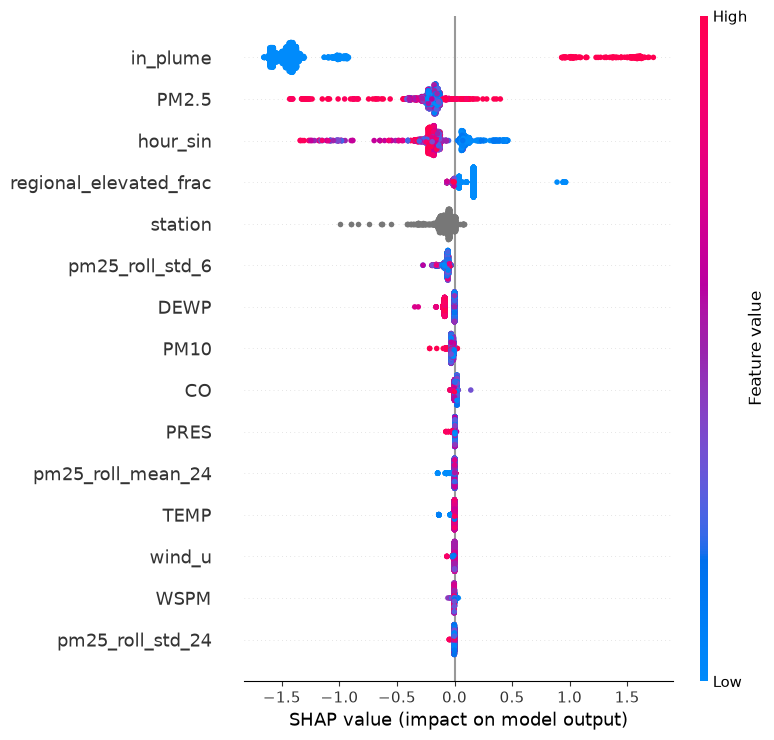


--- SHAP bar plot: t+3h ---


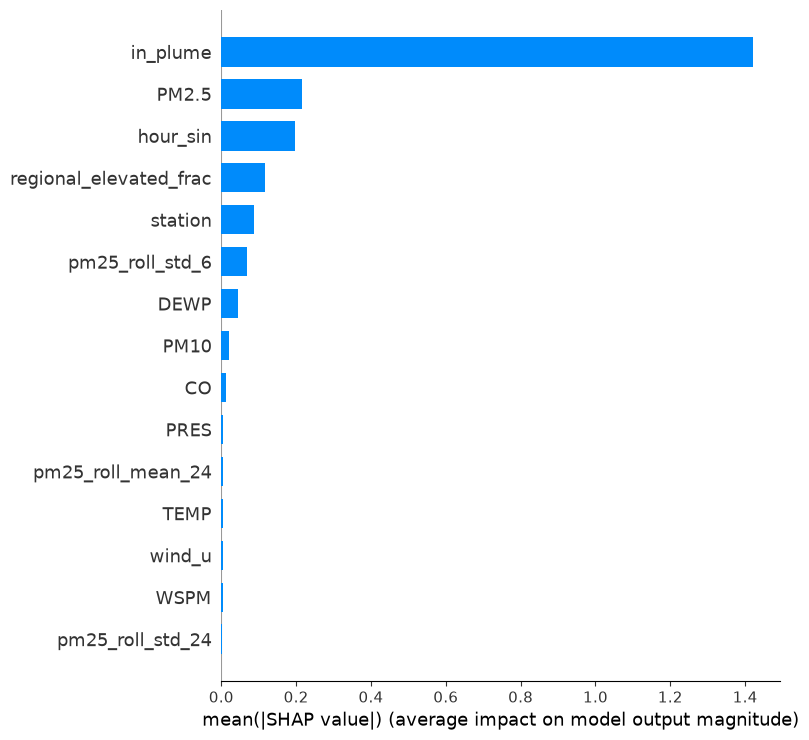


Top 10 SHAP features for t+3h:
in_plume                  1.422000
PM2.5                     0.216395
hour_sin                  0.198024
regional_elevated_frac    0.116541
station                   0.087339
pm25_roll_std_6           0.069142
DEWP                      0.044693
PM10                      0.020079
CO                        0.011485
PRES                      0.005385
dtype: float64


In [16]:
def run_shap(model, X_test, horizon, max_display=15, sample_size=2000):
    X_sample = X_test.sample(min(sample_size, len(X_test)), random_state=42).copy()
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    print(f"\n--- SHAP summary plot: t+{horizon}h ---")
    shap.summary_plot(shap_values, X_sample, max_display=max_display, show=True)

    print(f"\n--- SHAP bar plot: t+{horizon}h ---")
    shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=max_display, show=True)

    mean_abs_shap = pd.Series(
        np.abs(shap_values).mean(axis=0), index=X_sample.columns
    ).sort_values(ascending=False)
    print(f"\nTop 10 SHAP features for t+{horizon}h:")
    print(mean_abs_shap.head(10))
    return mean_abs_shap

shap_importances = {}
for h in HORIZONS:
    X_test, y_test = test_sets[h]
    shap_importances[h] = run_shap(models[h], X_test, h)

## 7. Save results

In [17]:
results_df.to_csv("model_results.csv", index=False)
print("Saved model_results.csv")
results_df

Saved model_results.csv


,horizon,f1,recall,precision,roc_auc,pr_auc,tp,fp,fn,tn
0,1,0.427256,0.962656,0.274556,0.997220,0.762344,232,613,9,27946
1,2,0.338648,0.925311,0.207249,0.972090,0.342738,223,853,18,27706
2,3,0.228469,0.792531,0.133473,0.958655,0.178510,191,1240,50,27319
